# Supplementary Fig. 30 — selection of control samples for mCA simulation

Selection of the control samples used to generate the simulated mCA test/training data. Scatter of **mean sequencing depth** vs the **coefficient of variation (CV)** of each
sample's PON-normalised read-depth ratios ('noise'), for the control samples across three sequencing libraries
(SLX_19285 ●, SLX_20125 ✕, SLX_20127 ▪). Within each library, samples were ranked by proximity to the library's
median depth and median CV; the three closest per library became the **training set** (black outline) and the
next three the **test set** (grey outline) — 9 training + 9 test. Selected samples are labelled.

## Data availability
Self-contained: the figure is drawn from a small cached **QC-metrics** table (no genotype / clinical data),
`Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/control_selection_depth_CV.csv` — one row per control sample with its
sequencing library, mean panel depth, PON-normalised-depth CV and train/test assignment.

## 1. Imports and colours

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
grey3 = '#969696'
grey4 = '#636363'

## 2. Load the cached per-sample depth / CV table

In [2]:
# Per-sample QC metrics for the 3 control libraries used to pick mCA-simulation control samples:
#   Raw_Depth = mean sequencing depth across panel regions; CV = SD/mean of the sample's
#   PON-normalised read-depth ratios (a 'noise' measure). 'set' marks the chosen training/test samples.
# Cached here (QC metrics only) so the figure reproduces without the large PON matrix / per-sample files.
stats_df = pd.read_csv('Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/control_selection_depth_CV.csv')
print(stats_df['set'].value_counts().to_dict(), '| n =', len(stats_df))

{'none': 18, 'training': 9, 'test': 9} | n = 36


## 3. Control-selection scatter (mean depth vs CV)

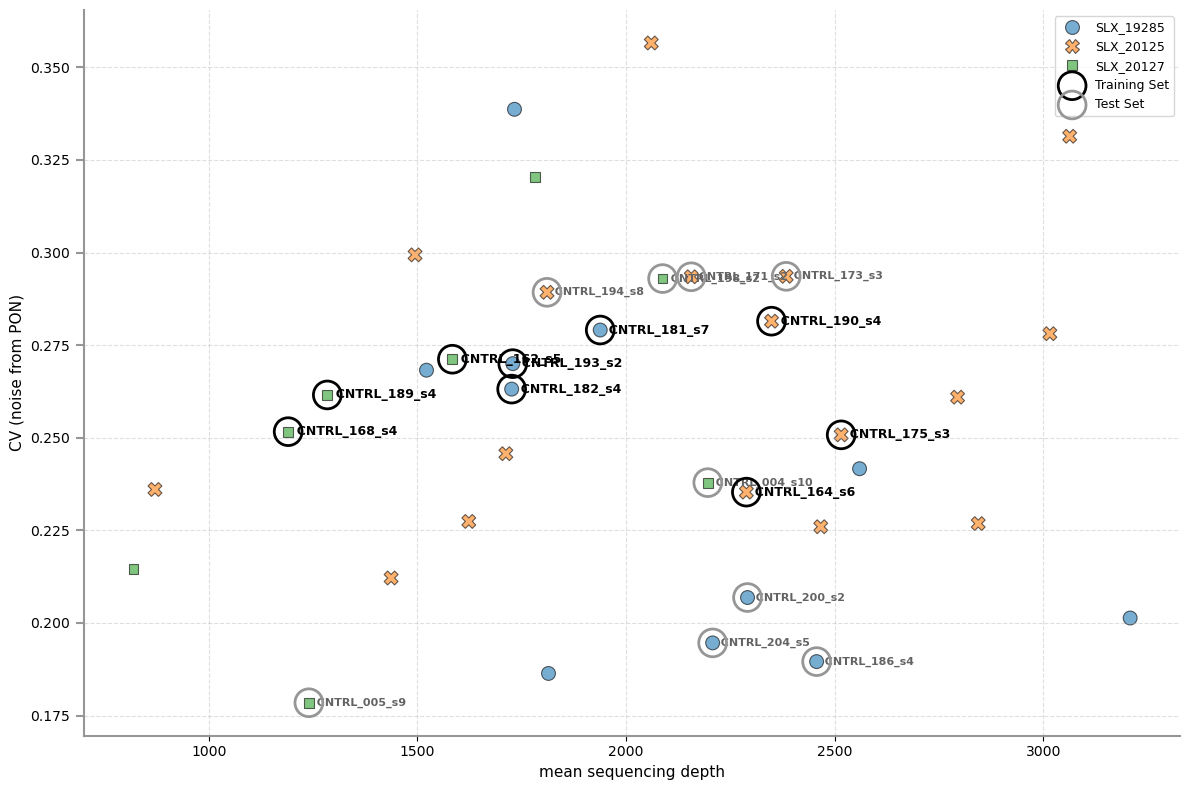

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

# all samples, coloured/shaped by sequencing library
sns.scatterplot(data=stats_df, x='Raw_Depth', y='CV', hue='Library', style='Library',
                s=100, alpha=0.6, edgecolor='k', ax=ax)

# training samples — black outline + label
tr = stats_df[stats_df['set'] == 'training']
ax.scatter(tr['Raw_Depth'], tr['CV'], s=400, facecolors='none', edgecolors='black',
           linewidth=2, zorder=10, label='Training Set')
for _, row in tr.iterrows():
    ax.text(row['Raw_Depth'], row['CV'], f"  {row['sample']}", fontsize=9,
            fontweight='bold', ha='left', va='center', color='black')

# test samples — grey outline + label
te = stats_df[stats_df['set'] == 'test']
ax.scatter(te['Raw_Depth'], te['CV'], s=400, facecolors='none', edgecolors=grey3,
           linewidth=2, zorder=10, label='Test Set')
for _, row in te.iterrows():
    ax.text(row['Raw_Depth'], row['CV'], f"  {row['sample']}", fontsize=8,
            fontweight='bold', ha='left', va='center', color=grey4)

ax.set_xlabel('mean sequencing depth', fontsize=11)
ax.set_ylabel('CV (noise from PON)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_linewidth(1.5)
    ax.spines[s].set_color(grey3)
ax.yaxis.set_tick_params(width=1.5, color=grey3, length=6)

plt.tight_layout()
plt.show()
